# Re-Training a Network in Browser

Follow the instructions in the next few steps to complete the training project without running out of memory on your nano. Make sure to consult the lessons in canvas for more detailed explanations about what is going on.

1. Run the cell below to copy the code you need to run this project.


In [1]:
!git clone https://github.com/dusty-nv/pytorch-classification.git; ls

Cloning into 'pytorch-classification'...
remote: Enumerating objects: 113, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 113 (delta 45), reused 54 (delta 39), pack-reused 50 (from 1)
Receiving objects: 100% (113/113), 33.20 KiB | 3.69 MiB/s, done.
Resolving deltas: 100% (58/58), done.
pytorch-classification	sample_data


2. Run the next cell to change directories into the directory where all the new code is, and install any required libraries to the runtime.

In [2]:
!cd pytorch-classification; pip install -r requirements.txt

3. Run the next cell to download the cat_dog data into the data directory and unzip it

In [15]:
!cd pytorch-classification/data; git clone https://github.com/zdflores/ai_productivity.git
!cd pytorch-classification/data/ai_productivity; git pull origin main

fatal: destination path 'ai_productivity' already exists and is not an empty directory.
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 11 (delta 2), reused 11 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (11/11), 1.05 KiB | 538.00 KiB/s, done.
From https://github.com/zdflores/ai_productivity
 * branch            main       -> FETCH_HEAD
   1db9a65..063b9c8  main       -> origin/main
Updating 1db9a65..063b9c8
Fast-forward
 dataset/test/productive/product 11.png               | Bin 0 -> 169111 bytes
 dataset/test/productive/product 19.png               | Bin 0 -> 490803 bytes
 dataset/test/productive/product 33.png               | Bin 0 -> 1093248 bytes
 dataset/test/productive/product 37.png               | Bin 0 -> 280304 bytes
 dataset/test/productive/product 42.png               | Bin 0 -> 293496 bytes
 dataset/{train => test}/unproductive/unproduct 3.png | Bin
 dataset/val

4. Change into the pytorch-classification directory and run the train script using the cat_dog dataset.

This cell will take a long time to run so be patient.

In [16]:
!cd pytorch-classification; python3 train.py -b 30 --model-dir=models/ai_productivity data/ai_productivity/dataset

2026-06-18 01:02:35.203847: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
To start tensorboard run:  tensorboard --log-dir=models/ai_productivity/tensorboard
=> using GPU 0 (Tesla T4)
=> dataset classes:  2  ['productive', 'unproductive']
=> using pre-trained model 'resnet18'
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weig

When the cell above is finished running, you can move the trained network back to the nano. There you can run the export script and then you should be able to use your newly trained network on your nano.

#Transfer the Network

Follow the steps below to transfer the network over to your nano.

1. In the files sidebar, open **pytorch-classification**. 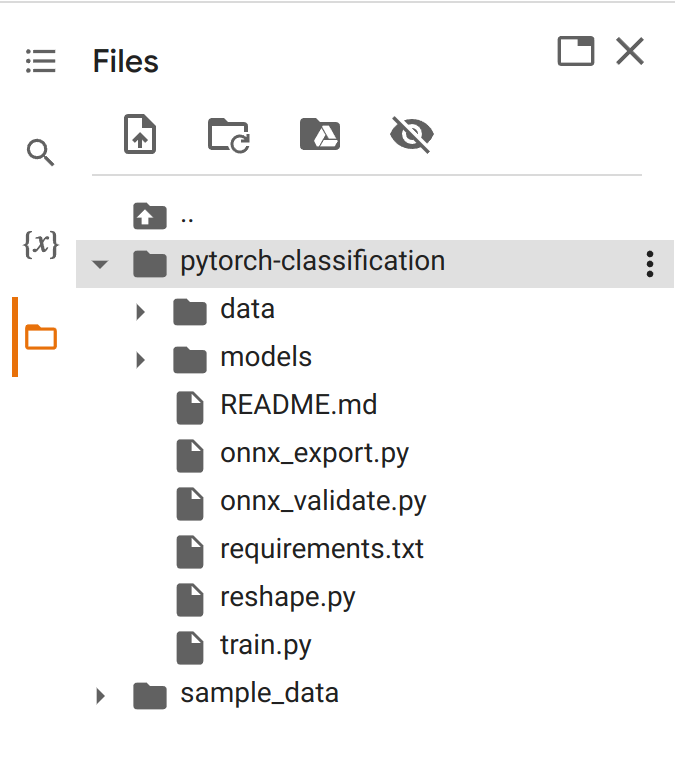
2. Under **models/cat_dog** you should see a file called model_best.pth.tar. Click the three dots next to that file, and select **Download**

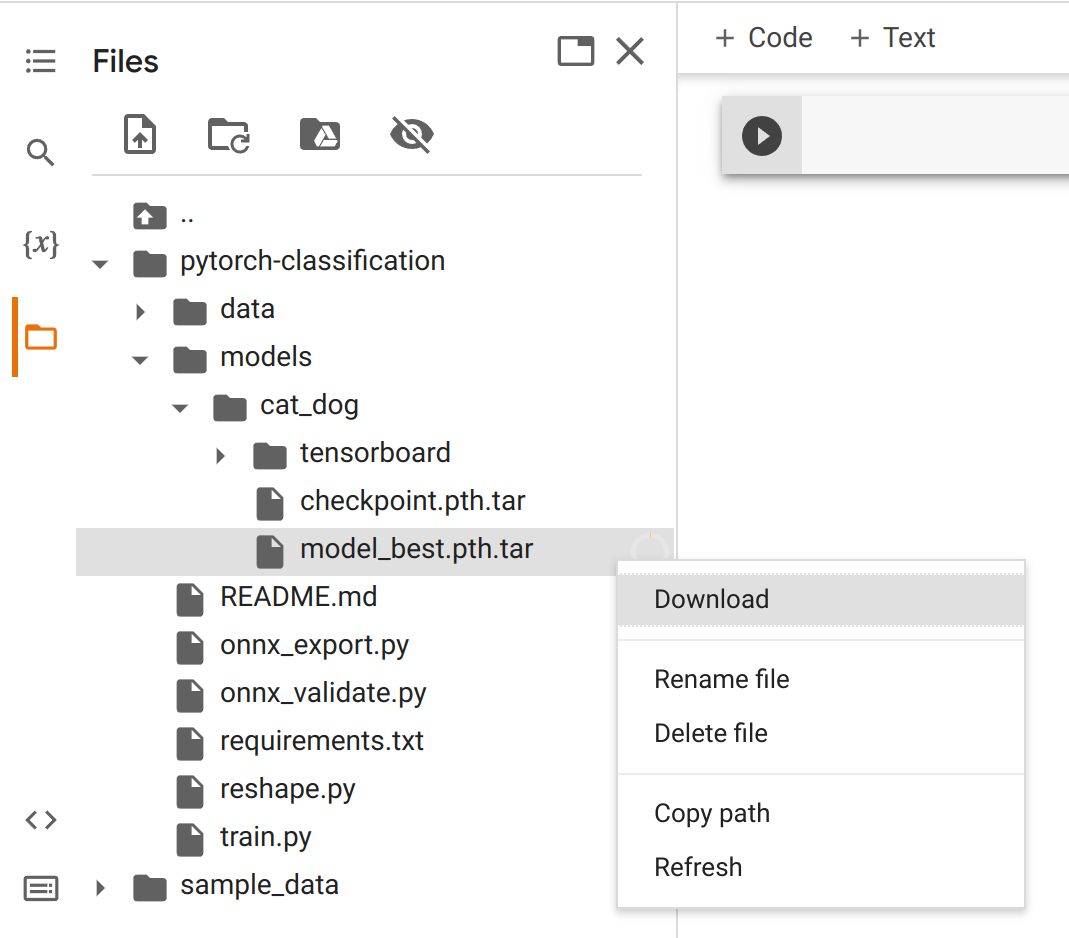

3. When the file downloads, make sure it's still named properly (it should be called **model_best.pth.tar**)
4. Open VSCode, and navigate to **/home/nvidia/jetson-inference/python/training/classification/models/cat_dog**. Drag and drop the downloaded file to the open directory in VSCode.
5. In the terminal, change directories into **/jetson-inference/python/training/classification/**.
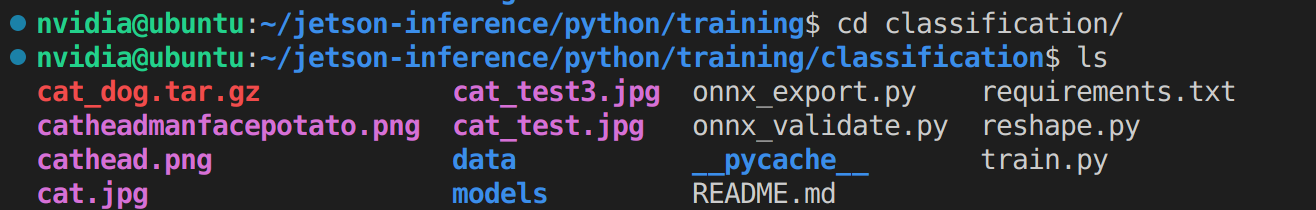

6. Use `ls models/cat_dog/` to make sure there is a best model file in that directory.
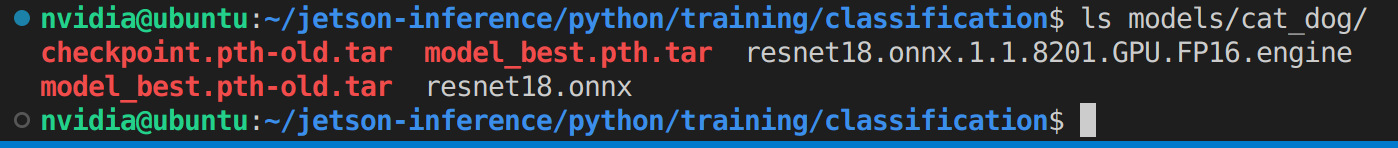

7. Run `python3 onnx_export.py --model-dir=models/cat_dog` to export the model.

8. Look in **jetson-inference/python/training/classification/models/cat_dog** to see your exported new model.

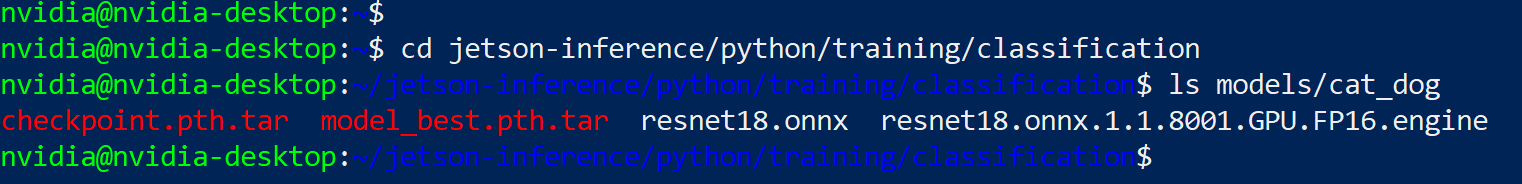

9. Use `ls models/cat_dog/` to make sure that the model is on the nano. You should see a file called **resnet18.onnx**.

10. Set the NET and DATASET variables
  * `NET=models/cat_dog`
  * `DATASET=data/cat_dog`

11. Run this command to see how it operates on an image from the cat folder.
`imagenet.py --model=$NET/resnet18.onnx --input_blob=input_0 --output_blob=output_0 --labels=$DATASET/labels.txt $DATASET/test/cat/01.jpg cat.jpg`

12. Open the new image in VSCode to see how your network works.